# QUIC Traffic Classifier
### Exploratory Data Analysis + XGBoost Model
---

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

FEATURES = [
    'packet_count', 'total_bytes', 'duration_s', 'bytes_per_sec',
    'mean_payload_len', 'std_payload_len', 'min_payload_len', 'max_payload_len',
    'mean_iat', 'std_iat', 'min_iat', 'max_iat',
    'burst_count', 'upload_ratio',
]

LABEL_COLORS = {
    'web':   '#4C72B0',
    'video': '#DD8452',
    'data':  '#55A868',
    'audio': '#C44E52',
}

print('imports ok')

imports ok


## 1. Load Data

In [10]:
train_raw = pd.read_csv('training_data.csv')
test_raw  = pd.read_csv('test_data.csv')

# drop audio - only 1 sample, not a usable class
train_df = train_raw[~train_raw['label'].isin(['audio'])].copy()
test_df  = test_raw[~test_raw['label'].isin(['audio'])].copy()

# combined for EDA
all_df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Train : {len(train_df)} rows')
print(f'Test  : {len(test_df)} rows')
print(f'Total : {len(all_df)} rows')
print(f'Classes: {sorted(all_df["label"].unique())}')
train_df.head()

Train : 664 rows
Test  : 151 rows
Total : 815 rows
Classes: ['data', 'video', 'web']


,service,session,window,ip_a,ip_b,packet_count,total_bytes,duration_s,bytes_per_sec,mean_payload_len,std_payload_len,min_payload_len,max_payload_len,mean_iat,std_iat,min_iat,max_iat,burst_count,upload_ratio,label
0,archive,1,0,172.17.93.240,172.217.24.110,31,3936,4.2421,927.83,126.97,196.84,30,1115,0.141404,0.684014,0.000000,3.816066,3,0.4194,web
1,archive,1,1,172.17.93.240,172.217.24.110,9,751,0.1414,5311.18,83.44,52.51,32,147,0.017675,0.020127,0.000000,0.053026,1,0.4444,web
2,archive,1,2,172.17.93.240,172.217.24.110,31,15127,0.0820,184423.56,487.97,538.24,29,1258,0.002734,0.006393,0.000000,0.033046,1,0.5161,web
3,archive,1,0,142.251.155.119,172.17.93.240,1029,905996,2.5139,360397.30,880.46,547.86,30,1258,0.002445,0.012468,0.000000,0.235369,5,0.2566,web
4,archive,1,1,142.251.155.119,172.17.93.240,10,360,3.3317,108.05,36.00,1.61,33,38,0.370191,0.785461,0.009439,2.582039,5,0.5000,web


## 2. Class Distribution

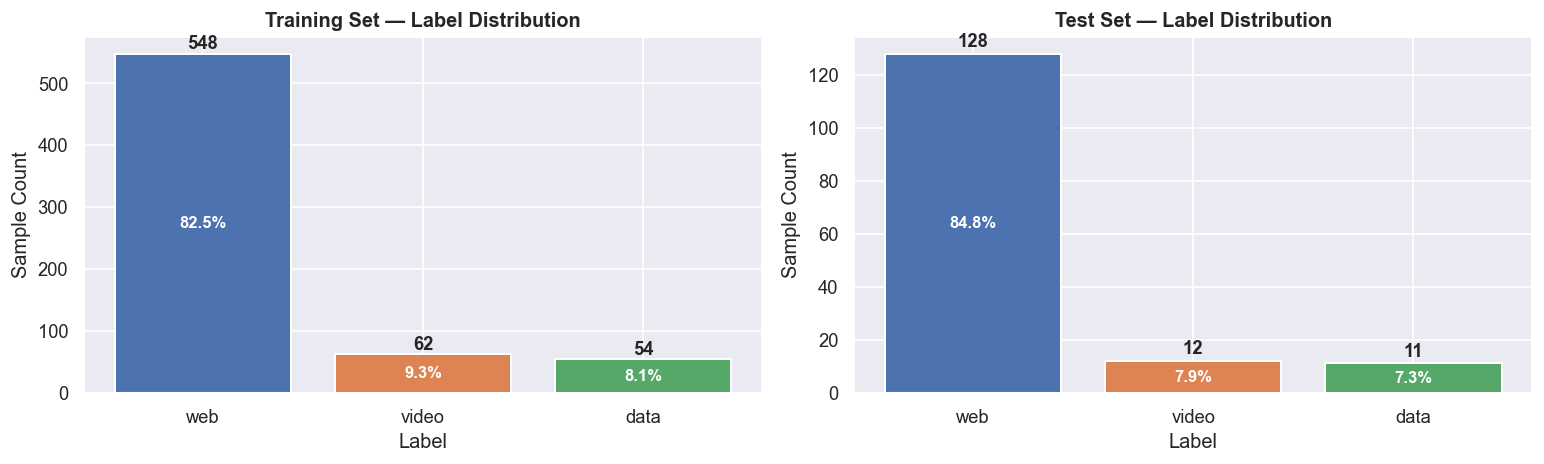


Class imbalance ratio (train):
label
web      10.1
video     1.1
data      1.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Training Set', 'Test Set']):
    counts = df['label'].value_counts()
    colors = [LABEL_COLORS.get(l, '#aaa') for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'{title} — Label Distribution', fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Sample Count')
    # add percentage labels
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'{pct:.1f}%', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plot_class_distribution.png', bbox_inches='tight')
plt.show()
print('\nClass imbalance ratio (train):')
counts = train_df['label'].value_counts()
print((counts / counts.min()).round(1).to_string())

## 3. Feature Distributions by Class

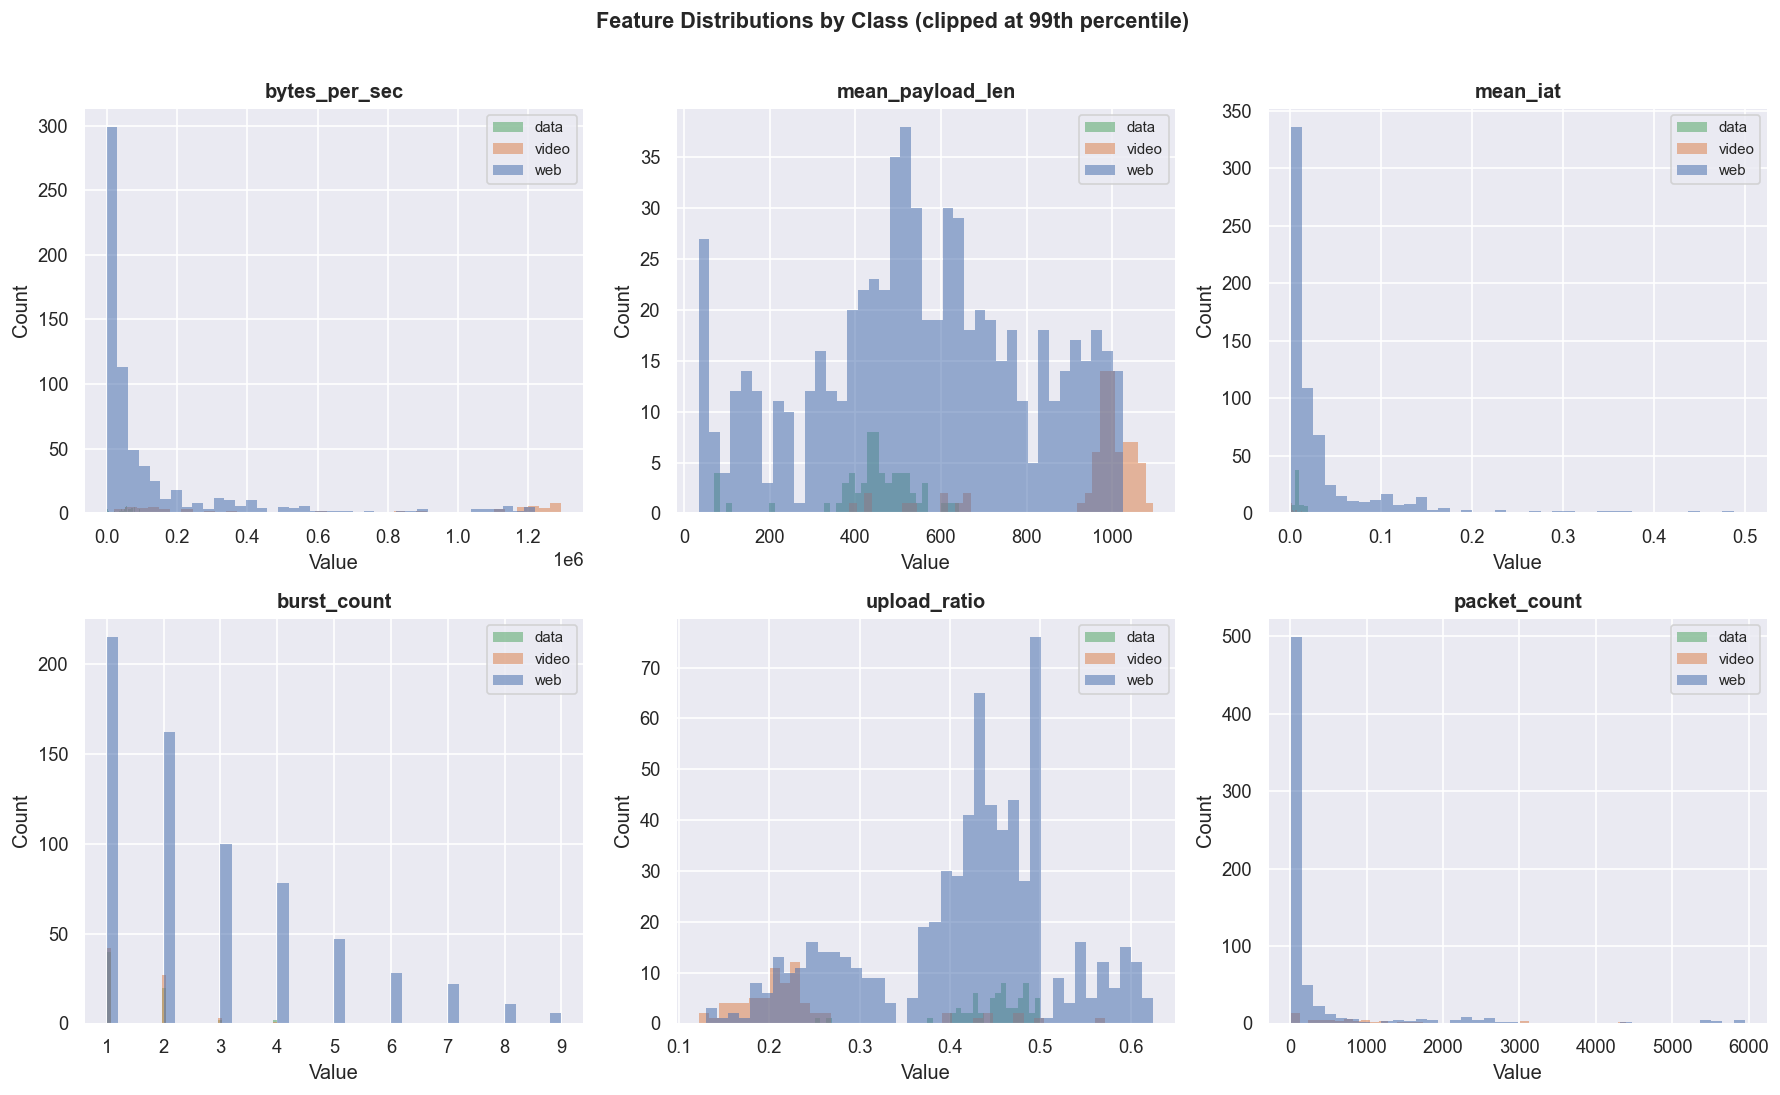

In [12]:
# most informative features for visual separation
key_features = ['bytes_per_sec', 'mean_payload_len', 'mean_iat', 'burst_count', 'upload_ratio', 'packet_count']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    for label in sorted(all_df['label'].unique()):
        vals = all_df[all_df['label'] == label][feat].dropna()
        # clip extreme outliers for readability
        p99 = vals.quantile(0.99)
        vals = vals[vals <= p99]
        ax.hist(vals, bins=40, alpha=0.55, label=label,
                color=LABEL_COLORS.get(label, '#aaa'), edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Class (clipped at 99th percentile)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', bbox_inches='tight')
plt.show()

## 4. Boxplots — Median and Spread per Class

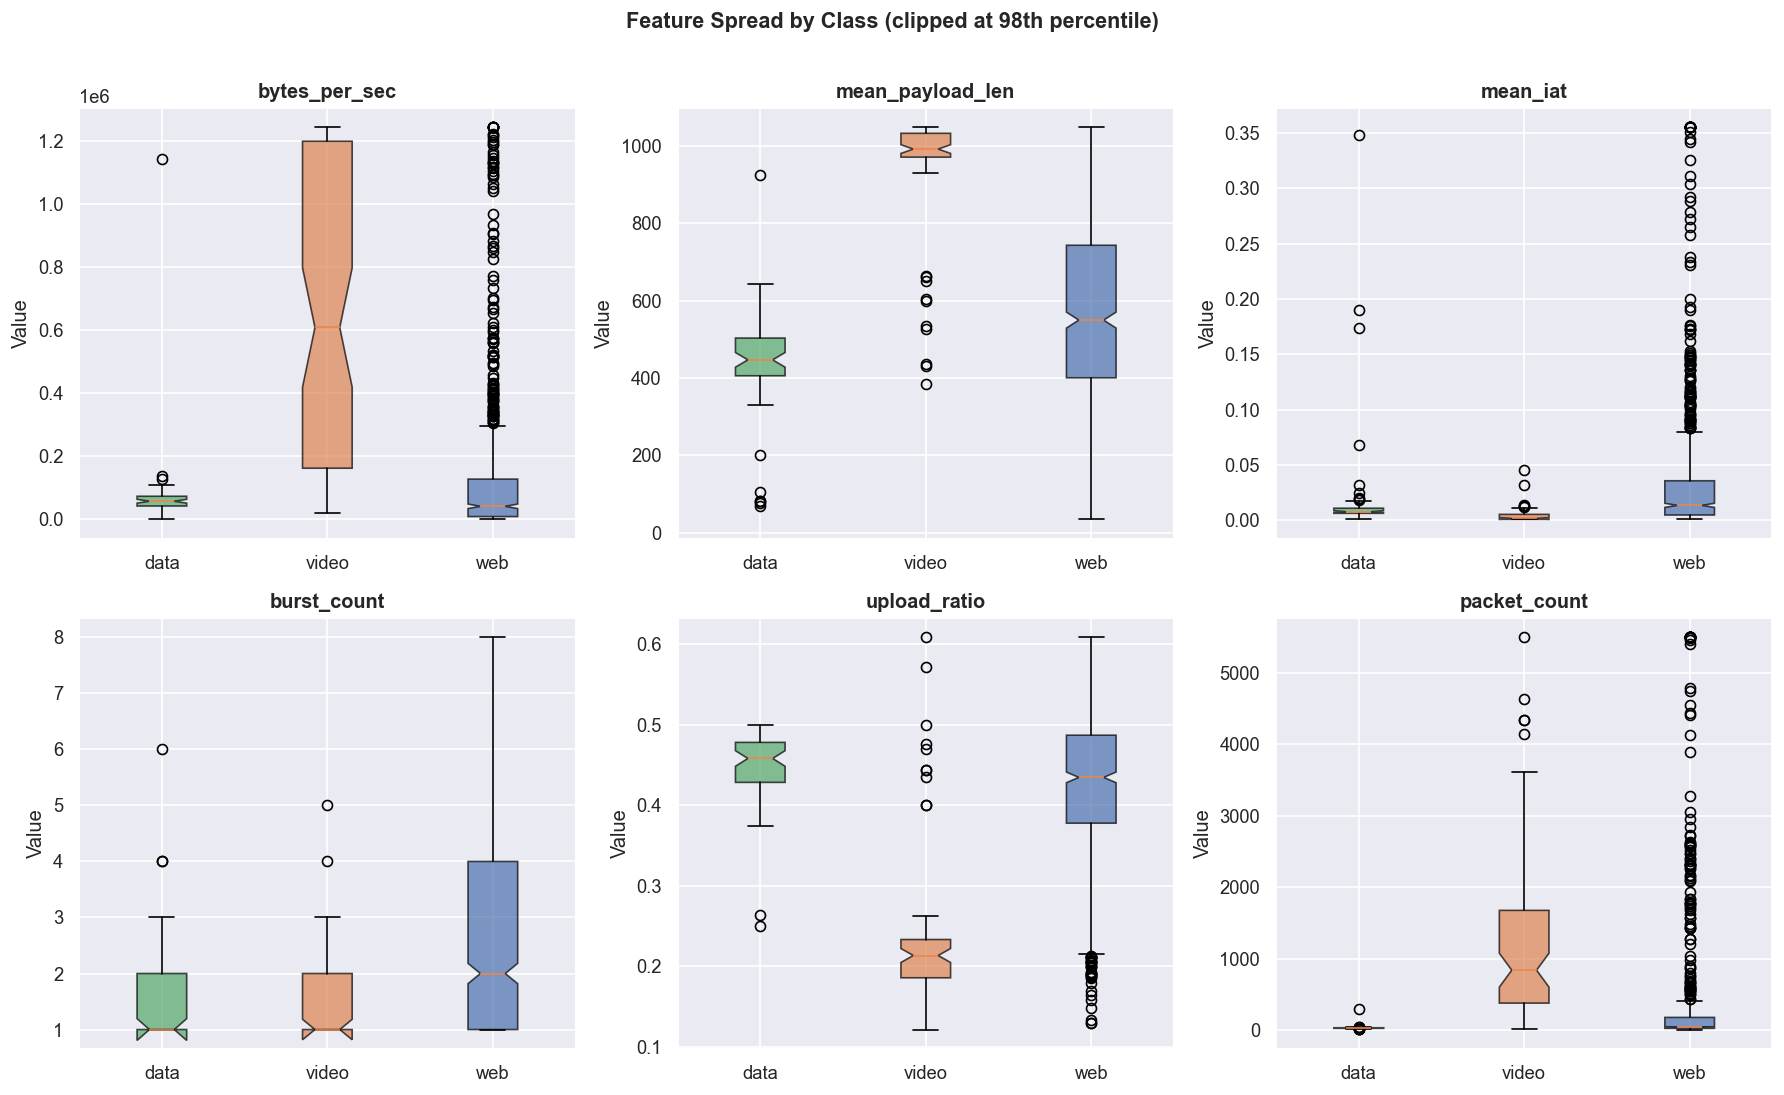

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    data_by_class = [
        all_df[all_df['label'] == label][feat].clip(
            upper=all_df[feat].quantile(0.98)
        ).dropna().values
        for label in sorted(all_df['label'].unique())
    ]
    labels_sorted = sorted(all_df['label'].unique())
    bp = ax.boxplot(data_by_class, labels=labels_sorted, patch_artist=True, notch=True)
    for patch, label in zip(bp['boxes'], labels_sorted):
        patch.set_facecolor(LABEL_COLORS.get(label, '#aaa'))
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Feature Spread by Class (clipped at 98th percentile)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_boxplots.png', bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

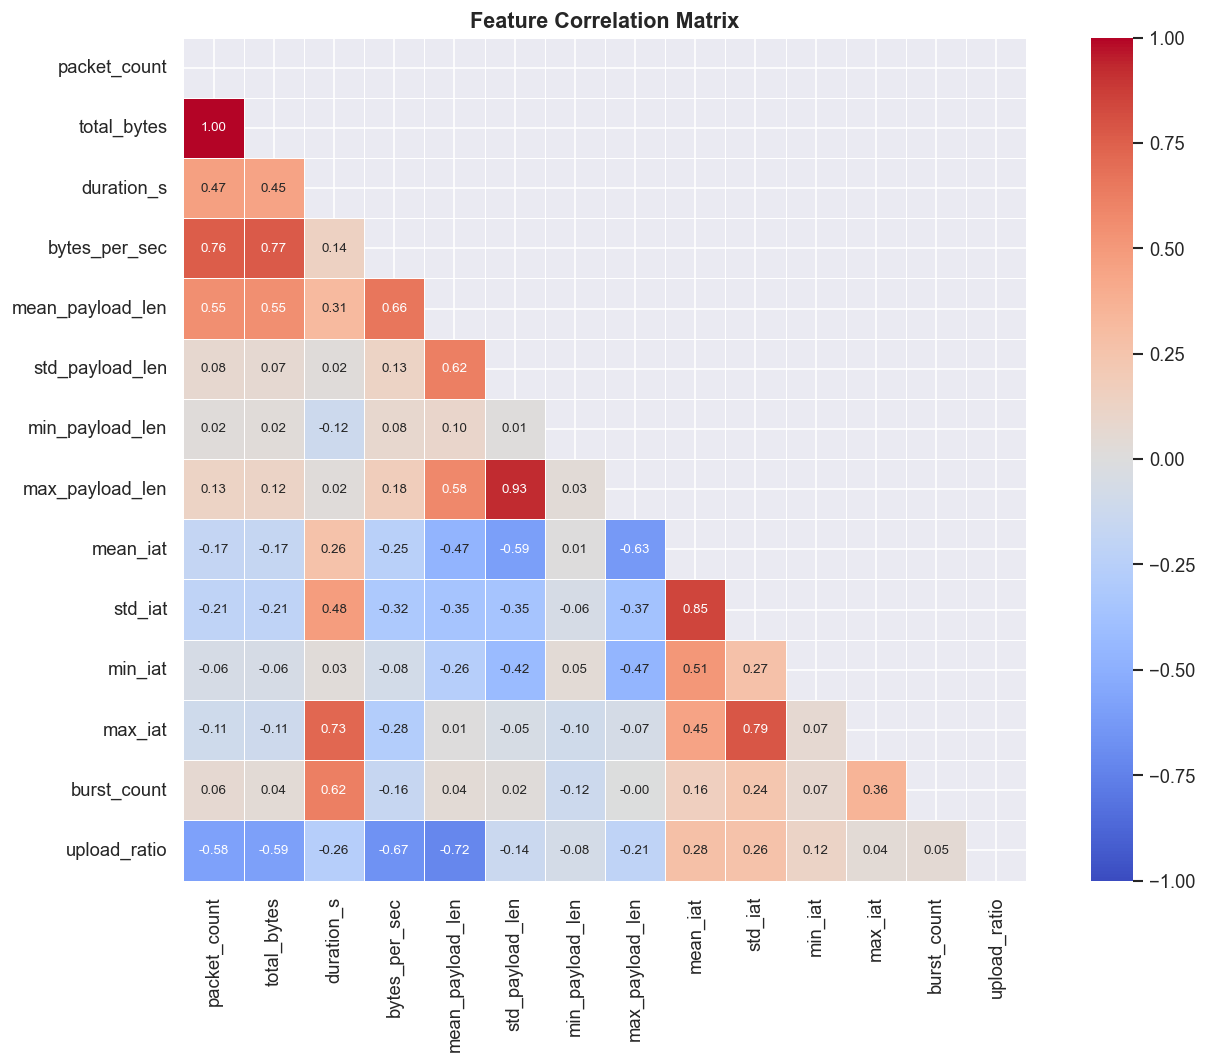

Highly correlated pairs (>0.85) — consider dropping one:
  total_bytes <-> packet_count : 0.999
  max_payload_len <-> std_payload_len : 0.926


In [14]:
corr = all_df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()

# flag high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr:
    print('Highly correlated pairs (>0.85) — consider dropping one:')
    for a, b, v in high_corr:
        print(f'  {a} <-> {b} : {v:.3f}')
else:
    print('No feature pairs with correlation > 0.85')

In [15]:
# use a sample to keep pairplot fast
sample = all_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 80), random_state=42)
)

pair_features = ['bytes_per_sec', 'mean_iat', 'burst_count', 'upload_ratio']
plot_df = sample[pair_features + ['label']].copy()

# clip for readability
for f in pair_features:
    plot_df[f] = plot_df[f].clip(upper=plot_df[f].quantile(0.97))

g = sns.pairplot(plot_df, hue='label', palette=LABEL_COLORS,
                 plot_kws={'alpha': 0.6, 's': 25},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Key Features by Class', y=1.02,
               fontsize=13, fontweight='bold')
plt.savefig('plot_pairplot.png', bbox_inches='tight')
plt.show()

KeyError: "['label'] not in index"

## 7. Per-Class Feature Summary Stats

In [ ]:
summary = all_df.groupby('label')[key_features].agg(['mean', 'median', 'std'])
summary.columns = ['_'.join(c) for c in summary.columns]
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
print('Per-class feature statistics:')
summary

## 8. Train XGBoost Model

In [ ]:
le = LabelEncoder()
le.fit(train_df['label'])
print(f'Classes: {list(le.classes_)}')

X_train = train_df[FEATURES].values
y_train = le.transform(train_df['label'])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df['label'])

# class weights to handle imbalance
counts  = np.bincount(y_train)
weights = len(y_train) / (len(counts) * counts)
sample_weights = np.array([weights[y] for y in y_train])

print(f'\nClass weights applied:')
for cls, w in zip(le.classes_, weights):
    print(f'  {cls}: {w:.3f}')

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
)
print('\ntraining complete')

## 9. Training Curve

In [ ]:
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train loss', color='#4C72B0')
ax.plot(val_loss,   label='Val loss',   color='#DD8452')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('Training Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_training_curve.png', bbox_inches='tight')
plt.show()

print(f'Final train loss : {train_loss[-1]:.4f}')
print(f'Final val loss   : {val_loss[-1]:.4f}')

## 10. Evaluation

In [ ]:
y_pred = model.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# row-normalized percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1],
            vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix (% of actual)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 11. Feature Importance

In [ ]:
fi = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
fi = fi.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4C72B0' if v > fi['importance'].median() else '#aec6e8' for v in fi['importance']]
bars = ax.barh(fi['feature'], fi['importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost Feature Importances', fontweight='bold')

for bar, val in zip(bars, fi['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(fi.sort_values('importance', ascending=False).head(5).to_string(index=False))

## 12. Save Model

In [ ]:
joblib.dump(model, 'model.pkl')
joblib.dump(le,    'label_encoder.pkl')
print('saved model.pkl and label_encoder.pkl')